In [1]:
import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy import stats
import random
random.seed(42)

In [2]:
demographics = pd.read_csv('../../dataset/human/demographics.csv')
subcortical_atlas = pd.read_csv('../../dataset/human/atlas-subcortical.csv')
aseg = pd.read_csv('../../dataset/human/aseg.csv').iloc[:, :-1]

In [3]:
df_hurst = pd.read_csv('../../derivatives/human/Hurst_schaefer100.csv')

In [4]:
df = df_hurst[df_hurst['type']=='cross']

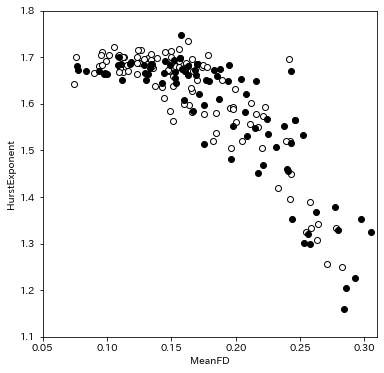

In [5]:
#FigS1C
figure = plt.figure(figsize=(6,6))
plt.scatter(df[df['Alcohol/No Alcohol']=='NoAlcohol'].mean_fd, df[df['Alcohol/No Alcohol']=='NoAlcohol'].iloc[:, :100].mean(axis=1), color='white', edgecolor='black')
plt.scatter(df[df['Alcohol/No Alcohol']=='Alcohol'].mean_fd, df[df['Alcohol/No Alcohol']=='Alcohol'].iloc[:, :100].mean(axis=1), color='black', edgecolor='black')
plt.xlim([0.05, 0.31])
plt.ylim([1.1, 1.8])
plt.xlabel('MeanFD')
plt.ylabel('HurstExponent')
plt.savefig('motion.eps')

In [6]:
no_alcohol_fd = df[df['Alcohol/No Alcohol'] == 'NoAlcohol'].mean_fd
no_alcohol_hurst = df[df['Alcohol/No Alcohol'] == 'NoAlcohol'].iloc[:, :100].mean(axis=1)

alcohol_fd = df[df['Alcohol/No Alcohol'] == 'Alcohol'].mean_fd
alcohol_hurst = df[df['Alcohol/No Alcohol'] == 'Alcohol'].iloc[:, :100].mean(axis=1)

# Calculate correlation coefficient and p-value for No Alcohol condition
corr_no_alcohol, p_val_no_alcohol = stats.pearsonr(no_alcohol_fd, no_alcohol_hurst)

# Calculate correlation coefficient and p-value for Alcohol condition
corr_alcohol, p_val_alcohol = stats.pearsonr(alcohol_fd, alcohol_hurst)

# Print results
print(f'No Alcohol condition: Correlation = {corr_no_alcohol}, P-value = {p_val_no_alcohol}')
print(f'Alcohol condition: Correlation = {corr_alcohol}, P-value = {p_val_alcohol}')

No Alcohol condition: Correlation = -0.8556463847595012, P-value = 1.624009364927561e-31
Alcohol condition: Correlation = -0.717601057131145, P-value = 4.0258675260826686e-16


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


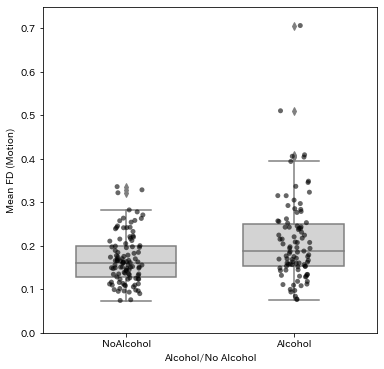

[-3.715638609116162, 0.00026365089893369233]


In [7]:
#FigS1A
plt.figure(figsize=(6, 6))
sns.boxplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, color='lightgray', width=0.6)
sns.stripplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, jitter=True, color='black', edgecolor='black', alpha=0.6)
plt.xlabel('Alcohol/No Alcohol')
plt.ylabel('Mean FD (Motion)')
plt.ylim([0, 0.75])
plt.savefig('motion_boxplot_with_scatter.eps')
plt.show()
no_alcohol = df[df['Alcohol/No Alcohol'] == 'NoAlcohol']['mean_fd']
alcohol = df[df['Alcohol/No Alcohol'] == 'Alcohol']['mean_fd']
t_stat, p_value = stats.ttest_ind(no_alcohol, alcohol)
print([t_stat,p_value])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


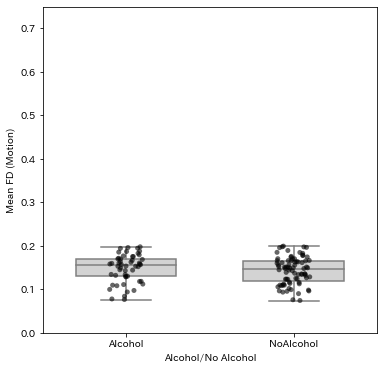

[-0.8762918214165408, 0.3825002721515104]


In [8]:
#FigS1D
plt.figure(figsize=(6, 6))
df = df[df.mean_fd<0.2]
sns.boxplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, color='lightgray', width=0.6)
sns.stripplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, jitter=True, color='black', edgecolor='black', alpha=0.6)
plt.xlabel('Alcohol/No Alcohol')
plt.ylabel('Mean FD (Motion)')
plt.ylim([0, 0.75])
plt.savefig('motion_boxplot_0.2.eps')
plt.show()
no_alcohol = df[df['Alcohol/No Alcohol'] == 'NoAlcohol']['mean_fd']
alcohol = df[df['Alcohol/No Alcohol'] == 'Alcohol']['mean_fd']
t_stat, p_value = stats.ttest_ind(no_alcohol, alcohol)
print([t_stat,p_value])